<a href="https://colab.research.google.com/github/ChristopherMwanginjoroge/deep-learning/blob/main/BGans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F # Import functional for activation functions
from torchvision import datasets,transforms
from torch.utils.data import DataLoader

transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))

])

train_data=datasets.MNIST(root='data',train=True,download=True,transform=transform)

dataloader=DataLoader(train_data,batch_size=64,shuffle=True)


class Generator(nn.Module):
  def __init__(self):
    super(Generator,self).__init__()

    self.fc1=nn.Linear(100,256)
    self.fc2=nn.Linear(256,512)
    self.fc3=nn.Linear(512,1024)
    self.fc4=nn.Linear(1024,28 * 28)



  def forward(self,x):
    x=F.relu(self.fc1(x)) # Changed to F.relu
    x=F.relu(self.fc2(x)) # Changed to F.relu
    x=F.relu(self.fc3(x)) # Changed to F.relu
    x=torch.tanh(self.fc4(x))

    x=x.view(-1,1,28 * 28)

    return x




class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator,self).__init__()

    # Input to Discriminator is a flattened 28x28 image (784 features)
    self.fc1=nn.Linear(28 * 28, 512)
    self.fc2=nn.Linear(512, 256)
    self.fc3=nn.Linear(256, 1) # Output is a single probability

    self.dropout = nn.Dropout(0.3)

  def forward(self, x):
        # Flatten the image
    x = x.view(-1, 28 * 28)


    x = F.leaky_relu(self.fc1(x), 0.2)
    x = self.dropout(x)
    x = F.leaky_relu(self.fc2(x), 0.2)
    x = self.dropout(x)
    x = F.leaky_relu(self.fc3(x), 0.2)
    x = self.dropout(x)
        # Sigmoid to output a probability between 0 (Fake) and 1 (Real)
    x = torch.sigmoid(x) # Apply sigmoid to the output of the last linear layer (fc3)
    return x

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 476kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.8MB/s]


In [2]:
generator = Generator() # Re-initialize the generator
discriminator = Discriminator() # Re-initialize the discriminator

print("Generator Architecture:")
print(generator)
print("\nDiscriminator Architecture:")
print(discriminator)

Generator Architecture:
Generator(
  (fc1): Linear(in_features=100, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=1024, bias=True)
  (fc4): Linear(in_features=1024, out_features=784, bias=True)
)

Discriminator Architecture:
Discriminator(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [3]:
import torch.optim as optim

g_optimizer=optim.Adam(generator.parameters(),lr=0.0002)
d_optimizer=optim.Adam(discriminator.parameters(),lr=0.0002)
criterion=nn.BCELoss()

epochs=50

for epoch in range(epochs):
  for real_images,_ in dataloader:
    batch_size=real_images.size(0)
    real_labels=torch.ones(batch_size,1)
    fake_labels=torch.zeros(batch_size,1)

    d_optimizer.zero_grad()

    # Use the discriminator instance, not the class
    real_outputs=discriminator(real_images)

    d_loss_real=criterion(real_outputs,real_labels)

    noise=torch.randn(batch_size,100)

    fake_images=generator(noise)

    fake_outputs=discriminator(fake_images.detach())

    d_loss_fake=criterion(fake_outputs,fake_labels) # Re-added d_loss_fake calculation

    d_loss=d_loss_real+d_loss_fake

    d_loss.backward()

    d_optimizer.step()


    g_optimizer.zero_grad()

    noise = torch.randn(batch_size, 100)
    fake_images = generator(noise)
    fake_outputs = discriminator(fake_images)
    g_loss = criterion(fake_outputs, real_labels)
    g_loss.backward()
    g_optimizer.step()

  if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Cop Loss (D): {d_loss.item():.4f} | Counterfeiter Loss (G): {g_loss.item():.4f}")

print("\nTraining complete! The Counterfeiter has finished practicing.")

Epoch [5/50] | Cop Loss (D): 1.6478 | Counterfeiter Loss (G): 1.0171
Epoch [10/50] | Cop Loss (D): 0.9756 | Counterfeiter Loss (G): 0.9519
Epoch [15/50] | Cop Loss (D): 0.9716 | Counterfeiter Loss (G): 0.9421
Epoch [20/50] | Cop Loss (D): 0.8872 | Counterfeiter Loss (G): 1.1356
Epoch [25/50] | Cop Loss (D): 1.0904 | Counterfeiter Loss (G): 1.2051
Epoch [30/50] | Cop Loss (D): 1.1987 | Counterfeiter Loss (G): 0.9250
Epoch [35/50] | Cop Loss (D): 1.3265 | Counterfeiter Loss (G): 0.8853
Epoch [40/50] | Cop Loss (D): 1.2525 | Counterfeiter Loss (G): 0.8290
Epoch [45/50] | Cop Loss (D): 1.3444 | Counterfeiter Loss (G): 0.8384
Epoch [50/50] | Cop Loss (D): 1.3305 | Counterfeiter Loss (G): 0.7217

Training complete! The Counterfeiter has finished practicing.


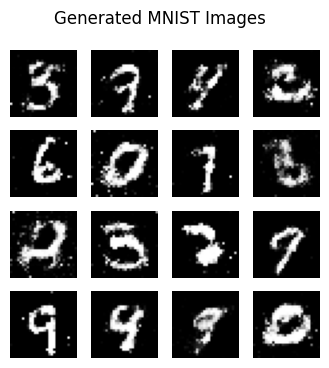

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some images with the trained generator
num_images = 16 # Number of images to generate and display
noise = torch.randn(num_images, 100)
fake_images = generator(noise).detach().cpu().numpy()

# Reshape images to 28x28 and denormalize for display
fake_images = fake_images.reshape(num_images, 28, 28)
fake_images = (fake_images * 0.5) + 0.5 # Denormalize to [0, 1]

# Plot the generated images
fig = plt.figure(figsize=(4, 4))
for i in range(num_images):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake_images[i], cmap='gray')
    plt.axis('off')
plt.suptitle('Generated MNIST Images')
plt.show()